In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Seed set successfully.")

Seed set successfully.


In [3]:
project_path = Path("/content/drive/MyDrive/ISL_GAN_FewShot_Project")

train_dir = project_path / "data" / "processed" / "fewshot" / "train"
val_dir   = project_path / "data" / "processed" / "fewshot" / "val"
test_dir  = project_path / "data" / "processed" / "fewshot" / "test"

output_dir = project_path / "data" / "processed" / "preprocessed"
output_dir.mkdir(parents=True, exist_ok=True)

print("Train:", train_dir)
print("Val:", val_dir)
print("Test:", test_dir)

Train: /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/processed/fewshot/train
Val: /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/processed/fewshot/val
Test: /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/processed/fewshot/test


In [4]:
for folder in [train_dir, val_dir, test_dir]:
    if not folder.exists():
        raise FileNotFoundError(f"Missing folder: {folder}")

print("All required folders are present.")

All required folders are present.


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Transforms ready.")

Transforms ready.


In [6]:
train_dataset = datasets.ImageFolder(root=str(train_dir), transform=train_transform)
val_dataset   = datasets.ImageFolder(root=str(val_dir), transform=eval_transform)
test_dataset  = datasets.ImageFolder(root=str(test_dir), transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:", class_names)

Number of classes: 35
Classes: ['1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [7]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Dataloaders created successfully.")

Dataloaders created successfully.


In [8]:
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 175
Validation samples: 6376
Test samples: 6376


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


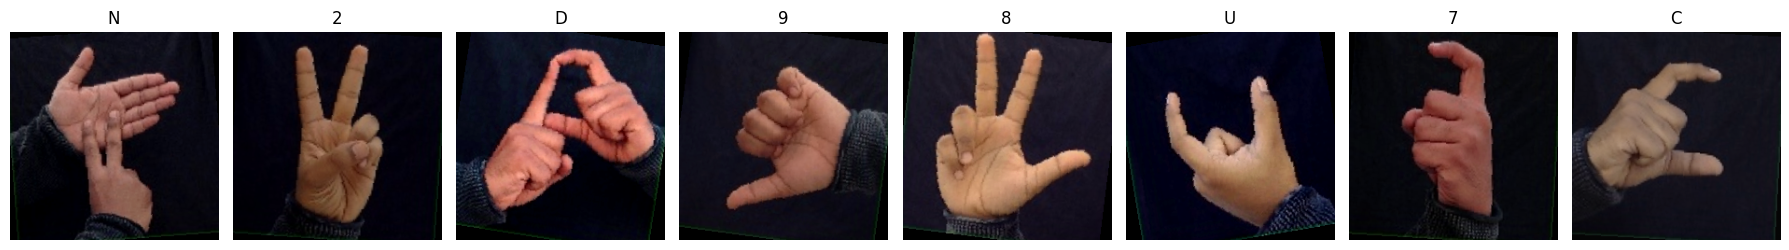

In [9]:

def denormalize(img_tensor):
    img = img_tensor.clone()
    img = img * 0.5 + 0.5
    img = torch.clamp(img, 0, 1)
    return img

def show_batch(loader, class_names, num_images=8):
    images, labels = next(iter(loader))
    images = images[:num_images]
    labels = labels[:num_images]

    fig, axes = plt.subplots(1, num_images, figsize=(18, 4))
    for i in range(num_images):
        img = denormalize(images[i]).permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i]])
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, class_names)

In [10]:
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

mapping_file = output_dir / "class_mapping.json"
with open(mapping_file, "w") as f:
    json.dump({
        "class_to_idx": class_to_idx,
        "idx_to_class": idx_to_class
    }, f, indent=4)

print("Saved class mapping to:", mapping_file)

Saved class mapping to: /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/processed/preprocessed/class_mapping.json


In [11]:
summary = {
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_classes": num_classes,
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "test_samples": len(test_dataset),
    "classes": class_names
}

summary_file = output_dir / "preprocessing_summary.json"
with open(summary_file, "w") as f:
    json.dump(summary, f, indent=4)

print("Saved preprocessing summary to:", summary_file)

Saved preprocessing summary to: /content/drive/MyDrive/ISL_GAN_FewShot_Project/data/processed/preprocessed/preprocessing_summary.json
